
# Cross-Language Ad Matching Research — Notebook 02
## RO2: Multilingual Transformer Fine-Tuning  
## RO3: Contrastive Learning with Hard Negatives

This notebook continues from `RO1_outputs.zip`.

### Experiments

| ID | Experiment |
|---|---|
| E1 | Character n-gram TF-IDF baseline from Notebook 01 |
| E2 | Zero-shot multilingual E5 retrieval model |
| E3 | Domain fine-tuning with positive ad pairs |
| E4 | Hard-negative contrastive fine-tuning |

### Research rule

- **Validation split** is used for model selection.
- **Test split** is evaluated only after the experiments are fixed.
- Wanted ads are treated as **queries**.
- Unique offering ads are treated as the searchable **document corpus**.
- The same offering ad never appears across different train/validation/test groups.

> Before running: **Runtime → Change runtime type → T4 GPU**.



## 1. Install reproducible library versions

The versions are pinned so that the notebook remains reproducible.


In [ ]:

!pip -q install \
    sentence-transformers==5.6.0 \
    faiss-cpu \
    datasets \
    accelerate \
    pandas \
    matplotlib \
    tqdm



## 2. Check the GPU

Do not continue with transformer training when the output says `GPU available: False`.


In [ ]:

import os
import gc
import json
import math
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss

from datasets import Dataset
from tqdm.auto import tqdm

from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses,
)
from sentence_transformers.training_args import BatchSamplers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )
else:
    raise RuntimeError(
        "GPU is not enabled. Select Runtime → Change runtime type → T4 GPU."
    )


PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4
GPU memory: 14.56 GB



## 3. Mount Google Drive

The trained models are large. Saving them to Google Drive prevents losing them when the Colab session ends.


In [ ]:

from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ad_matching_research"
)
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "day2_results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/ad_matching_research



## 4. Upload `RO1_outputs.zip`

Upload the ZIP file generated by Notebook 01.


In [ ]:

from google.colab import files

uploaded = files.upload()
zip_files = [
    name for name in uploaded
    if name.lower().endswith(".zip")
]

if not zip_files:
    raise FileNotFoundError(
        "Upload the RO1_outputs.zip file."
    )

RO1_ZIP = Path("/content") / zip_files[0]
RO1_DIR = Path("/content/RO1_outputs")

if RO1_DIR.exists():
    shutil.rmtree(RO1_DIR)

RO1_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(RO1_ZIP, "r") as archive:
    archive.extractall(RO1_DIR)

print("Extracted files:")
for path in sorted(RO1_DIR.iterdir()):
    print("-", path.name)


Saving RO1_outputs.zip to RO1_outputs.zip
Extracted files:
- category_1_distribution.png
- category_1_summary.csv
- category_2_distribution.png
- category_2_summary.csv
- clean_pairs_with_splits.csv
- offering_corpus.csv
- test_pairs.csv
- tfidf_category_metrics.csv
- tfidf_overall_metrics.csv
- tfidf_script_metrics.csv
- tfidf_subcategory_metrics.csv
- tfidf_test_query_results.csv
- train_pairs.csv
- validation_pairs.csv
- wanted_script_distribution.png
- wanted_script_summary.csv



## 5. Load and validate the prepared data


In [ ]:

train_df = pd.read_csv(RO1_DIR / "train_pairs.csv")
val_df = pd.read_csv(RO1_DIR / "validation_pairs.csv")
test_df = pd.read_csv(RO1_DIR / "test_pairs.csv")
corpus_df = pd.read_csv(RO1_DIR / "offering_corpus.csv")

required_pair_columns = {
    "wanted_ad",
    "offering_ad",
    "offering_id",
    "category_1",
    "category_2",
    "wanted_script_group",
}
required_corpus_columns = {
    "offering_id",
    "offering_ad",
    "category_1",
    "category_2",
}

for name, frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    missing = required_pair_columns - set(frame.columns)
    if missing:
        raise ValueError(
            f"{name} is missing columns: {sorted(missing)}"
        )

missing = required_corpus_columns - set(corpus_df.columns)
if missing:
    raise ValueError(
        f"offering_corpus is missing columns: {sorted(missing)}"
    )

train_ids = set(train_df["offering_id"])
val_ids = set(val_df["offering_id"])
test_ids = set(test_df["offering_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Leakage check passed.")
print("Train pairs:", len(train_df))
print("Validation pairs:", len(val_df))
print("Test pairs:", len(test_df))
print("Unique corpus offerings:", len(corpus_df))


Leakage check passed.
Train pairs: 38180
Validation pairs: 8160
Test pairs: 8149
Unique corpus offerings: 39019



## 6. Configuration

`multilingual-e5-small` is selected because it is multilingual, retrieval-oriented, and practical on Colab Free.

The E5 family requires:

- `query: ` before wanted ads
- `passage: ` before offering ads

The maximum sequence length is reduced to 256 tokens to fit Colab GPU memory.


In [ ]:

BASE_MODEL_NAME = "intfloat/multilingual-e5-small"

MAX_SEQ_LENGTH = 256
ENCODE_BATCH_SIZE = 128

RO2_BATCH_SIZE = 32
RO3_BATCH_SIZE = 24

RO2_EPOCHS = 1
RO3_EPOCHS = 1

RO2_LEARNING_RATE = 2e-5
RO3_LEARNING_RATE = 1e-5

TOP_K = 10
HARD_NEGATIVE_SEARCH_K = 80
HARD_NEGATIVE_MARGIN = 0.02

# Set a smaller number only if the Colab session is unstable.
# None means use every unique training offering.
MAX_UNIQUE_TRAIN_PAIRS = None

RO2_MODEL_PATH = MODEL_DIR / "ro2_domain_finetuned_e5"
RO3_MODEL_PATH = MODEL_DIR / "ro3_hard_negative_e5"

CONFIG = {
    "seed": SEED,
    "base_model": BASE_MODEL_NAME,
    "max_seq_length": MAX_SEQ_LENGTH,
    "encode_batch_size": ENCODE_BATCH_SIZE,
    "ro2_batch_size": RO2_BATCH_SIZE,
    "ro3_batch_size": RO3_BATCH_SIZE,
    "ro2_epochs": RO2_EPOCHS,
    "ro3_epochs": RO3_EPOCHS,
    "ro2_learning_rate": RO2_LEARNING_RATE,
    "ro3_learning_rate": RO3_LEARNING_RATE,
    "hard_negative_search_k": HARD_NEGATIVE_SEARCH_K,
    "hard_negative_margin": HARD_NEGATIVE_MARGIN,
    "max_unique_train_pairs": MAX_UNIQUE_TRAIN_PAIRS,
}

with open(
    RESULT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(CONFIG, file, indent=2)

display(pd.Series(CONFIG, name="value").to_frame())


,value
seed,42
base_model,intfloat/multilingual-e5-small
max_seq_length,256
encode_batch_size,128
ro2_batch_size,32
ro3_batch_size,24
ro2_epochs,1
ro3_epochs,1
ro2_learning_rate,0.00002
ro3_learning_rate,0.00001



## 7. Prepare unique training pairs

One wanted query is selected per unique offering ad.

This prevents the same offering from becoming a false in-batch negative.


In [ ]:

train_unique = (
    train_df.sample(frac=1, random_state=SEED)
    .drop_duplicates("offering_id")
    .reset_index(drop=True)
)

if MAX_UNIQUE_TRAIN_PAIRS is not None:
    train_unique = (
        train_unique.sample(
            n=min(MAX_UNIQUE_TRAIN_PAIRS, len(train_unique)),
            random_state=SEED,
        )
        .reset_index(drop=True)
    )

print("Unique training pairs:", len(train_unique))
display(
    train_unique[
        [
            "wanted_ad",
            "offering_ad",
            "category_1",
            "category_2",
        ]
    ].head(3)
)


Unique training pairs: 27313


,wanted_ad,offering_ad,category_1,category_2
0,2005-2010 අතර Toyota Noah වර්ගයේ Diesel රථයක් ...,"Toyota NOAH 2006 (Used). Contact: 077 xxxxxxx,...",Vehicle,van
1,Looking for a used LG 6kg Inverter Direct Driv...,LG 6.0 Kg Inverter DD Front Load Washing Machi...,Electronics,Electronic Home Appliances
2,"Urgently looking for a Toyota LH30B, around 19...","Toyota Lh30b In Galle Full Condition , Power S...",Vehicle,van



# Evaluation Functions


In [ ]:

def query_text(text):
    return "query: " + str(text)

def passage_text(text):
    return "passage: " + str(text)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def encode_texts(
    model,
    texts,
    prefix_type,
    batch_size=ENCODE_BATCH_SIZE,
):
    if prefix_type == "query":
        prepared = [query_text(text) for text in texts]
    elif prefix_type == "passage":
        prepared = [passage_text(text) for text in texts]
    elif prefix_type == "none":
        prepared = [str(text) for text in texts]
    else:
        raise ValueError(
            "prefix_type must be query, passage, or none"
        )

    embeddings = model.encode(
        prepared,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return embeddings.astype("float32")

def calculate_metrics(
    retrieved_indices,
    target_indices,
):
    ranks = []

    for retrieved, target in zip(
        retrieved_indices,
        target_indices,
    ):
        positions = np.where(retrieved == target)[0]
        rank = (
            int(positions[0] + 1)
            if len(positions)
            else None
        )
        ranks.append(rank)

    metrics = {}

    for k in [1, 5, 10]:
        hits = np.array(
            [
                rank is not None and rank <= k
                for rank in ranks
            ],
            dtype=float,
        )
        metrics[f"Recall@{k}"] = hits.mean()
        metrics[f"Precision@{k}"] = (
            hits.mean() / k
        )

    metrics["MRR@10"] = np.mean(
        [
            1.0 / rank
            if rank is not None and rank <= 10
            else 0.0
            for rank in ranks
        ]
    )

    metrics["nDCG@10"] = np.mean(
        [
            1.0 / np.log2(rank + 1)
            if rank is not None and rank <= 10
            else 0.0
            for rank in ranks
        ]
    )

    metrics["Top10_Failures"] = sum(
        rank is None for rank in ranks
    )

    return metrics, ranks

def evaluate_retrieval(
    model,
    eval_df,
    corpus_df,
    experiment_name,
):
    print(
        f"\nEncoding corpus for {experiment_name}..."
    )
    corpus_embeddings = encode_texts(
        model,
        corpus_df["offering_ad"].tolist(),
        prefix_type="passage",
    )

    print(
        f"\nEncoding {len(eval_df)} queries..."
    )
    query_embeddings = encode_texts(
        model,
        eval_df["wanted_ad"].tolist(),
        prefix_type="query",
    )

    index = faiss.IndexFlatIP(
        corpus_embeddings.shape[1]
    )
    index.add(corpus_embeddings)

    scores, indices = index.search(
        query_embeddings,
        TOP_K,
    )

    offering_to_index = {
        offering_id: index_value
        for index_value, offering_id
        in enumerate(corpus_df["offering_id"])
    }

    targets = np.array(
        [
            offering_to_index[offering_id]
            for offering_id in eval_df["offering_id"]
        ],
        dtype=np.int64,
    )

    metrics, ranks = calculate_metrics(
        indices,
        targets,
    )

    result_df = eval_df[
        [
            "wanted_id",
            "wanted_ad",
            "offering_id",
            "category_1",
            "category_2",
            "wanted_script_group",
        ]
    ].copy()

    result_df["rank_at_10"] = ranks
    result_df["top1_offering_id"] = [
        corpus_df.iloc[row[0]]["offering_id"]
        for row in indices
    ]
    result_df["top1_score"] = scores[:, 0]

    return metrics, result_df

def grouped_metrics(
    result_df,
    group_column,
):
    rows = []

    for value, group in result_df.groupby(
        group_column
    ):
        ranks = group["rank_at_10"].tolist()

        dummy_indices = []
        dummy_targets = []

        # Reconstruct hit positions only for metric reuse.
        for rank in ranks:
            if pd.isna(rank):
                dummy_indices.append(
                    np.arange(10) + 100
                )
                dummy_targets.append(-1)
            else:
                retrieved = np.arange(10) + 100
                retrieved[int(rank) - 1] = 1
                dummy_indices.append(retrieved)
                dummy_targets.append(1)

        metrics, _ = calculate_metrics(
            np.array(dummy_indices),
            np.array(dummy_targets),
        )

        rows.append(
            {
                group_column: value,
                "query_count": len(group),
                **metrics,
            }
        )

    return pd.DataFrame(rows).sort_values(
        "query_count",
        ascending=False,
    )



# E2 — Zero-Shot Multilingual Transformer Baseline


In [ ]:

zero_shot_model = SentenceTransformer(
    BASE_MODEL_NAME
)
zero_shot_model.max_seq_length = MAX_SEQ_LENGTH

zero_val_metrics, zero_val_results = (
    evaluate_retrieval(
        zero_shot_model,
        val_df,
        corpus_df,
        "E2 Zero-shot E5 validation",
    )
)

display(
    pd.DataFrame(
        [zero_val_metrics],
        index=["E2 Zero-shot E5"],
    ).round(4)
)

zero_val_results.to_csv(
    RESULT_DIR / "e2_zero_shot_validation_results.csv",
    index=False,
)

del zero_shot_model
clear_memory()


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...


Encoding corpus for E2 Zero-shot E5 validation...


Batches:   0%|          | 0/305 [00:00<?, ?it/s]


Encoding 8160 queries...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
E2 Zero-shot E5,0.3414,0.3414,0.5275,0.1055,0.6056,0.0606,0.422,0.4658,3218



# E3 — RO2 Domain Fine-Tuning

The model is trained with matching wanted/offering pairs.

`MultipleNegativesRankingLoss` makes the matched offering the positive item while using other offerings in the batch as negatives.

This teaches the multilingual transformer the semantics of Sri Lankan classified advertisements.


In [ ]:

ro2_training_frame = pd.DataFrame(
    {
        "anchor": train_unique[
            "wanted_ad"
        ].map(query_text),
        "positive": train_unique[
            "offering_ad"
        ].map(passage_text),
    }
)

ro2_dataset = Dataset.from_pandas(
    ro2_training_frame,
    preserve_index=False,
)

print(ro2_dataset)
display(ro2_training_frame.head(2))


Dataset({
    features: ['anchor', 'positive'],
    num_rows: 27313
})


,anchor,positive
0,query: 2005-2010 අතර Toyota Noah වර්ගයේ Diesel...,passage: Toyota NOAH 2006 (Used). Contact: 077...
1,query: Looking for a used LG 6kg Inverter Dire...,passage: LG 6.0 Kg Inverter DD Front Load Wash...


In [ ]:

ro2_model = SentenceTransformer(
    BASE_MODEL_NAME
)
ro2_model.max_seq_length = MAX_SEQ_LENGTH

ro2_loss = losses.MultipleNegativesRankingLoss(
    model=ro2_model
)

ro2_args = SentenceTransformerTrainingArguments(
    output_dir=str(
        PROJECT_DIR / "checkpoints_ro2"
    ),
    num_train_epochs=RO2_EPOCHS,
    per_device_train_batch_size=RO2_BATCH_SIZE,
    learning_rate=RO2_LEARNING_RATE,
    warmup_ratio=0.10,
    fp16=True,
    bf16=False,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=100,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=2,
)

ro2_trainer = SentenceTransformerTrainer(
    model=ro2_model,
    args=ro2_args,
    train_dataset=ro2_dataset,
    loss=ro2_loss,
)

ro2_trainer.train()

ro2_model.save(str(RO2_MODEL_PATH))
print("RO2 model saved to:", RO2_MODEL_PATH)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss
100,0.593460
200,0.034156
300,0.031127
400,0.028271
500,0.028667
600,0.019260
700,0.026368
800,0.025084


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RO2 model saved to: /content/drive/MyDrive/ad_matching_research/models/ro2_domain_finetuned_e5


In [ ]:

ro2_val_metrics, ro2_val_results = (
    evaluate_retrieval(
        ro2_model,
        val_df,
        corpus_df,
        "E3 RO2 validation",
    )
)

display(
    pd.DataFrame(
        [ro2_val_metrics],
        index=["E3 RO2 fine-tuned"],
    ).round(4)
)

ro2_val_results.to_csv(
    RESULT_DIR / "e3_ro2_validation_results.csv",
    index=False,
)



Encoding corpus for E3 RO2 validation...


Batches:   0%|          | 0/305 [00:00<?, ?it/s]


Encoding 8160 queries...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
E3 RO2 fine-tuned,0.5723,0.5723,0.8051,0.161,0.877,0.0877,0.6723,0.7216,1004



# Hard-Negative Mining

A hard negative is an incorrect offering advertisement that looks semantically similar to the query.

Selection order:

1. Same subcategory and safely below the positive similarity
2. Same main category and safely below the positive similarity
3. Any non-matching retrieved offering as fallback

The selected negative and its mining strategy are saved for research transparency.


In [ ]:

train_corpus = (
    train_unique[
        [
            "offering_id",
            "offering_ad",
            "category_1",
            "category_2",
        ]
    ]
    .drop_duplicates("offering_id")
    .reset_index(drop=True)
)

train_query_embeddings = encode_texts(
    ro2_model,
    train_unique["wanted_ad"].tolist(),
    prefix_type="query",
)

train_corpus_embeddings = encode_texts(
    ro2_model,
    train_corpus["offering_ad"].tolist(),
    prefix_type="passage",
)

train_index = faiss.IndexFlatIP(
    train_corpus_embeddings.shape[1]
)
train_index.add(train_corpus_embeddings)

mining_scores, mining_indices = train_index.search(
    train_query_embeddings,
    HARD_NEGATIVE_SEARCH_K,
)

local_target_index = {
    offering_id: index_value
    for index_value, offering_id
    in enumerate(train_corpus["offering_id"])
}

hard_negative_rows = []

for row_position, row in tqdm(
    train_unique.iterrows(),
    total=len(train_unique),
):
    target_index = local_target_index[
        row["offering_id"]
    ]

    positive_score = float(
        np.dot(
            train_query_embeddings[row_position],
            train_corpus_embeddings[target_index],
        )
    )

    selected_index = None
    selected_score = None
    selected_strategy = None

    # Pass 1: same subcategory with a margin.
    for candidate_index, candidate_score in zip(
        mining_indices[row_position],
        mining_scores[row_position],
    ):
        if candidate_index == target_index:
            continue

        candidate = train_corpus.iloc[
            candidate_index
        ]

        if (
            candidate["category_2"]
            == row["category_2"]
            and candidate_score
            <= positive_score - HARD_NEGATIVE_MARGIN
        ):
            selected_index = int(candidate_index)
            selected_score = float(candidate_score)
            selected_strategy = (
                "same_subcategory_margin"
            )
            break

    # Pass 2: same main category with a margin.
    if selected_index is None:
        for candidate_index, candidate_score in zip(
            mining_indices[row_position],
            mining_scores[row_position],
        ):
            if candidate_index == target_index:
                continue

            candidate = train_corpus.iloc[
                candidate_index
            ]

            if (
                candidate["category_1"]
                == row["category_1"]
                and candidate_score
                <= positive_score
                - HARD_NEGATIVE_MARGIN
            ):
                selected_index = int(candidate_index)
                selected_score = float(candidate_score)
                selected_strategy = (
                    "same_category_margin"
                )
                break

    # Pass 3: first non-target candidate.
    if selected_index is None:
        for candidate_index, candidate_score in zip(
            mining_indices[row_position],
            mining_scores[row_position],
        ):
            if candidate_index != target_index:
                selected_index = int(candidate_index)
                selected_score = float(candidate_score)
                selected_strategy = "fallback_non_target"
                break

    if selected_index is None:
        raise RuntimeError(
            f"No hard negative found at row {row_position}"
        )

    negative = train_corpus.iloc[selected_index]

    hard_negative_rows.append(
        {
            "anchor": query_text(
                row["wanted_ad"]
            ),
            "positive": passage_text(
                row["offering_ad"]
            ),
            "negative": passage_text(
                negative["offering_ad"]
            ),
            "anchor_offering_id": row[
                "offering_id"
            ],
            "negative_offering_id": negative[
                "offering_id"
            ],
            "category_1": row["category_1"],
            "category_2": row["category_2"],
            "positive_score": positive_score,
            "negative_score": selected_score,
            "score_margin": (
                positive_score - selected_score
            ),
            "mining_strategy": selected_strategy,
        }
    )

hard_negative_df = pd.DataFrame(
    hard_negative_rows
)

hard_negative_df.to_csv(
    RESULT_DIR / "hard_negative_triplets.csv",
    index=False,
)

print("Hard-negative triplets:", len(hard_negative_df))
display(
    hard_negative_df[
        [
            "category_1",
            "category_2",
            "positive_score",
            "negative_score",
            "score_margin",
            "mining_strategy",
        ]
    ].head()
)

display(
    hard_negative_df[
        "mining_strategy"
    ].value_counts().to_frame("count")
)


Batches:   0%|          | 0/214 [00:00<?, ?it/s]

Batches:   0%|          | 0/214 [00:00<?, ?it/s]

  0%|          | 0/27313 [00:00<?, ?it/s]

Hard-negative triplets: 27313


,category_1,category_2,positive_score,negative_score,score_margin,mining_strategy
0,Vehicle,van,0.714322,0.681557,0.032765,same_subcategory_margin
1,Electronics,Electronic Home Appliances,0.888013,0.738096,0.149917,same_subcategory_margin
2,Vehicle,van,0.824623,0.665220,0.159403,same_subcategory_margin
3,Vehicle,car,0.890499,0.808666,0.081833,same_subcategory_margin
4,Vehicle,car,0.752540,0.719963,0.032577,same_subcategory_margin


,count
mining_strategy,
same_subcategory_margin,26869
fallback_non_target,423
same_category_margin,21



# E4 — RO3 Hard-Negative Contrastive Fine-Tuning

The RO2 model is further trained using:

- Anchor wanted ad
- Correct offering ad
- Difficult but incorrect offering ad

This directly addresses RO3.


In [ ]:

ro3_dataset = Dataset.from_pandas(
    hard_negative_df[
        [
            "anchor",
            "positive",
            "negative",
        ]
    ],
    preserve_index=False,
)

ro3_loss = losses.MultipleNegativesRankingLoss(
    model=ro2_model
)

ro3_args = SentenceTransformerTrainingArguments(
    output_dir=str(
        PROJECT_DIR / "checkpoints_ro3"
    ),
    num_train_epochs=RO3_EPOCHS,
    per_device_train_batch_size=RO3_BATCH_SIZE,
    learning_rate=RO3_LEARNING_RATE,
    warmup_ratio=0.10,
    fp16=True,
    bf16=False,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=100,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=2,
)

ro3_trainer = SentenceTransformerTrainer(
    model=ro2_model,
    args=ro3_args,
    train_dataset=ro3_dataset,
    loss=ro3_loss,
)

ro3_trainer.train()

# ro2_model now contains the RO3 weights.
ro2_model.save(str(RO3_MODEL_PATH))
print("RO3 model saved to:", RO3_MODEL_PATH)


Step,Training Loss
100,0.369292
200,0.338506
300,0.305936
400,0.285010
500,0.297986
600,0.278370
700,0.263427
800,0.271455
900,0.281433
1000,0.280834


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RO3 model saved to: /content/drive/MyDrive/ad_matching_research/models/ro3_hard_negative_e5


In [ ]:

ro3_val_metrics, ro3_val_results = (
    evaluate_retrieval(
        ro2_model,
        val_df,
        corpus_df,
        "E4 RO3 validation",
    )
)

display(
    pd.DataFrame(
        [ro3_val_metrics],
        index=[
            "E4 RO3 hard-negative contrastive"
        ],
    ).round(4)
)

ro3_val_results.to_csv(
    RESULT_DIR / "e4_ro3_validation_results.csv",
    index=False,
)



Encoding corpus for E4 RO3 validation...


Batches:   0%|          | 0/305 [00:00<?, ?it/s]


Encoding 8160 queries...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
E4 RO3 hard-negative contrastive,0.6347,0.6347,0.8474,0.1695,0.9093,0.0909,0.727,0.7711,740



# Validation Comparison and Model Selection


In [ ]:

validation_comparison = pd.DataFrame(
    [
        {
            "Experiment": "E2 Zero-shot E5",
            **zero_val_metrics,
        },
        {
            "Experiment": "E3 RO2 fine-tuned",
            **ro2_val_metrics,
        },
        {
            "Experiment":
                "E4 RO3 hard-negative contrastive",
            **ro3_val_metrics,
        },
    ]
).sort_values(
    "MRR@10",
    ascending=False,
)

validation_comparison.to_csv(
    RESULT_DIR / "validation_comparison.csv",
    index=False,
)

display(validation_comparison.round(4))

best_experiment = validation_comparison.iloc[
    0
]["Experiment"]

print(
    "Best validation experiment:",
    best_experiment,
)

with open(
    RESULT_DIR / "best_validation_experiment.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(str(best_experiment))


,Experiment,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
2,E4 RO3 hard-negative contrastive,0.6347,0.6347,0.8474,0.1695,0.9093,0.0909,0.7270,0.7711,740
1,E3 RO2 fine-tuned,0.5723,0.5723,0.8051,0.1610,0.8770,0.0877,0.6723,0.7216,1004
0,E2 Zero-shot E5,0.3414,0.3414,0.5275,0.1055,0.6056,0.0606,0.4220,0.4658,3218


Best validation experiment: E4 RO3 hard-negative contrastive



# Final Test Evaluation

All experiment settings are now fixed.

This section generates the final thesis comparison table.


In [ ]:

# Remove the active training model before loading
# models one by one.
del ro3_trainer
del ro2_trainer
del ro3_loss
del ro2_loss
del ro2_model
clear_memory()


In [ ]:

def load_and_test(
    model_source,
    experiment_name,
    output_filename,
):
    model = SentenceTransformer(
        str(model_source)
    )
    model.max_seq_length = MAX_SEQ_LENGTH

    metrics, results = evaluate_retrieval(
        model,
        test_df,
        corpus_df,
        experiment_name,
    )

    results.to_csv(
        RESULT_DIR / output_filename,
        index=False,
    )

    del model
    clear_memory()

    return metrics, results

zero_test_metrics, zero_test_results = (
    load_and_test(
        BASE_MODEL_NAME,
        "E2 Zero-shot E5 test",
        "e2_zero_shot_test_results.csv",
    )
)

ro2_test_metrics, ro2_test_results = (
    load_and_test(
        RO2_MODEL_PATH,
        "E3 RO2 test",
        "e3_ro2_test_results.csv",
    )
)

ro3_test_metrics, ro3_test_results = (
    load_and_test(
        RO3_MODEL_PATH,
        "E4 RO3 test",
        "e4_ro3_test_results.csv",
    )
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Encoding corpus for E2 Zero-shot E5 test...


Batches:   0%|          | 0/305 [00:00<?, ?it/s]


Encoding 8149 queries...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Encoding corpus for E4 RO3 test...


Batches:   0%|          | 0/305 [00:00<?, ?it/s]


Encoding 8149 queries...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]


## Add the Notebook 01 TF-IDF result


In [ ]:

tfidf_metrics_df = pd.read_csv(
    RO1_DIR / "tfidf_overall_metrics.csv",
    index_col=0,
)

tfidf_row = tfidf_metrics_df.iloc[0].to_dict()

# Precision@K is derived because the dataset
# contains one known relevant offering per query.
for k in [1, 5, 10]:
    tfidf_row[f"Precision@{k}"] = (
        tfidf_row[f"Recall@{k}"] / k
    )

tfidf_row["Top10_Failures"] = (
    len(test_df)
    - round(
        tfidf_row["Recall@10"]
        * len(test_df)
    )
)

test_comparison = pd.DataFrame(
    [
        {
            "Experiment":
                "E1 TF-IDF character n-gram",
            **tfidf_row,
        },
        {
            "Experiment":
                "E2 Zero-shot multilingual E5",
            **zero_test_metrics,
        },
        {
            "Experiment":
                "E3 RO2 domain fine-tuned",
            **ro2_test_metrics,
        },
        {
            "Experiment":
                "E4 RO3 hard-negative contrastive",
            **ro3_test_metrics,
        },
    ]
)

metric_order = [
    "Experiment",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "MRR@10",
    "nDCG@10",
    "Top10_Failures",
]

test_comparison = test_comparison[
    metric_order
].sort_values(
    "MRR@10",
    ascending=False,
)

test_comparison.to_csv(
    RESULT_DIR / "final_test_comparison.csv",
    index=False,
)

display(test_comparison.round(4))


,Experiment,Recall@1,Recall@5,Recall@10,Precision@1,Precision@5,Precision@10,MRR@10,nDCG@10,Top10_Failures
3,E4 RO3 hard-negative contrastive,0.6289,0.8496,0.9050,0.6289,0.1699,0.0905,0.7236,0.7677,774
2,E3 RO2 domain fine-tuned,0.5717,0.8083,0.8747,0.5717,0.1617,0.0875,0.6728,0.7217,1021
1,E2 Zero-shot multilingual E5,0.3351,0.5323,0.6092,0.3351,0.1065,0.0609,0.4191,0.4645,3185
0,E1 TF-IDF character n-gram,0.2524,0.4160,0.4883,0.2524,0.0832,0.0488,0.3229,0.3623,4170



# Category-Wise and Script-Wise Evaluation

The best fine-tuned model is selected using validation MRR@10.


In [ ]:

if (
    ro3_val_metrics["MRR@10"]
    >= ro2_val_metrics["MRR@10"]
):
    selected_name = (
        "E4 RO3 hard-negative contrastive"
    )
    selected_results = ro3_test_results
    selected_model_path = RO3_MODEL_PATH
else:
    selected_name = "E3 RO2 domain fine-tuned"
    selected_results = ro2_test_results
    selected_model_path = RO2_MODEL_PATH

category_results = grouped_metrics(
    selected_results,
    "category_1",
)

subcategory_results = grouped_metrics(
    selected_results,
    "category_2",
)

script_results = grouped_metrics(
    selected_results,
    "wanted_script_group",
)

category_results.to_csv(
    RESULT_DIR / "best_model_category_metrics.csv",
    index=False,
)
subcategory_results.to_csv(
    RESULT_DIR / "best_model_subcategory_metrics.csv",
    index=False,
)
script_results.to_csv(
    RESULT_DIR / "best_model_script_metrics.csv",
    index=False,
)

print("Selected fine-tuned model:", selected_name)
print("Model path:", selected_model_path)

print("\nMain-category performance")
display(category_results.round(4))

print("\nScript-group performance")
display(script_results.round(4))

with open(
    RESULT_DIR / "selected_model_path.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(str(selected_model_path))


Selected fine-tuned model: E4 RO3 hard-negative contrastive
Model path: /content/drive/MyDrive/ad_matching_research/models/ro3_hard_negative_e5

Main-category performance


,category_1,query_count,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
0,Electronics,3015,0.5954,0.5954,0.8192,0.1638,0.8786,0.0879,0.6908,0.7363,366
2,Vehicle,2707,0.6875,0.6875,0.8759,0.1752,0.9206,0.0921,0.7676,0.8048,215
1,Property,2427,0.6053,0.6053,0.8578,0.1716,0.9205,0.0920,0.7152,0.7652,193



Script-group performance


,wanted_script_group,query_count,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10,MRR@10,nDCG@10,Top10_Failures
0,latin_only,4380,0.6023,0.6023,0.8308,0.1662,0.8936,0.0894,0.7020,0.7485,466
1,sinhala_latin,2890,0.6927,0.6927,0.8869,0.1774,0.9273,0.0927,0.7742,0.8116,210
2,sinhala_only,877,0.5519,0.5519,0.8198,0.1640,0.8883,0.0888,0.6644,0.7186,98
3,tamil_only,2,0.5000,0.5000,1.0000,0.2000,1.0000,0.1000,0.7500,0.8155,0



# Result Visualizations


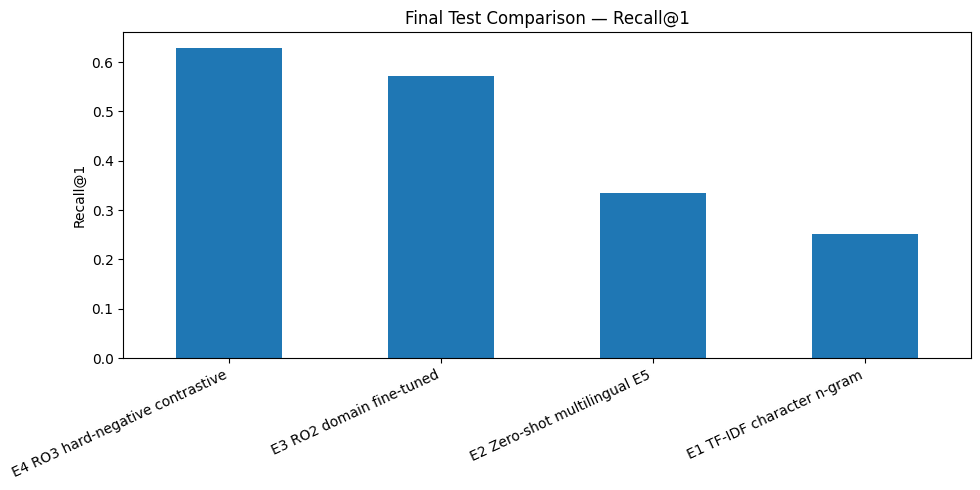

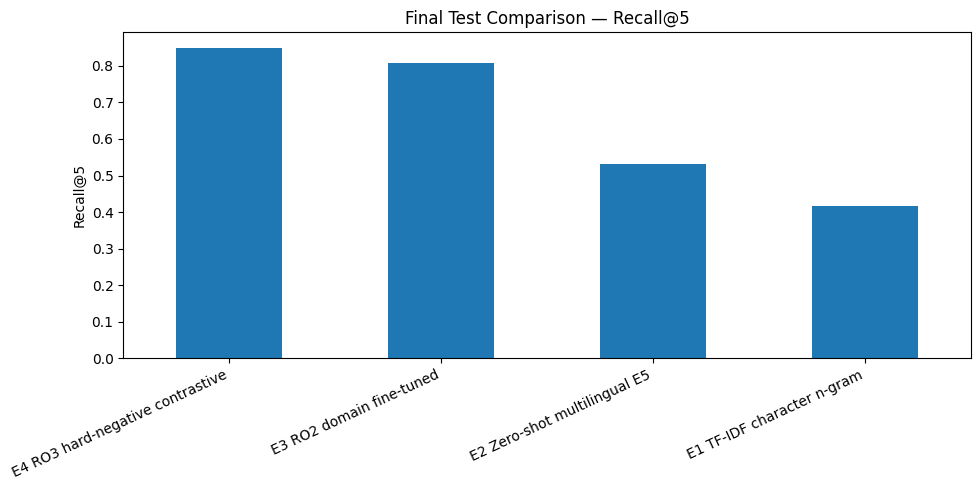

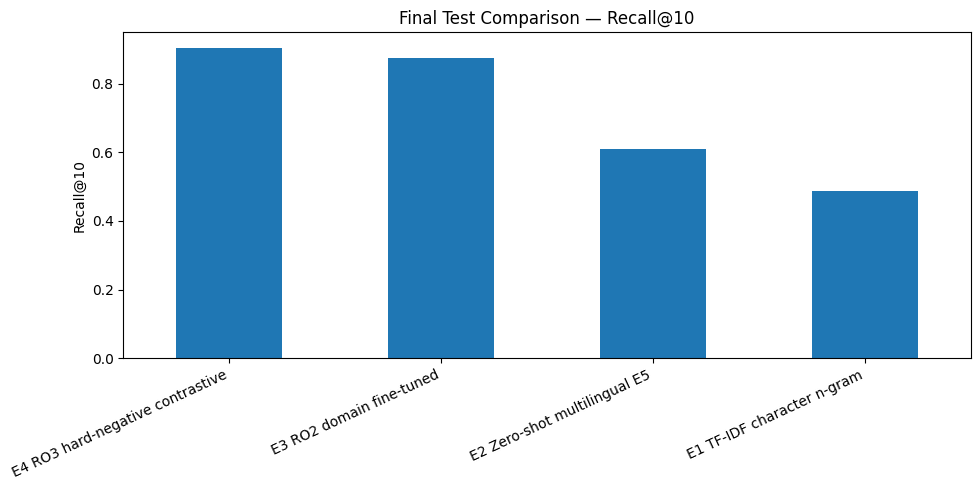

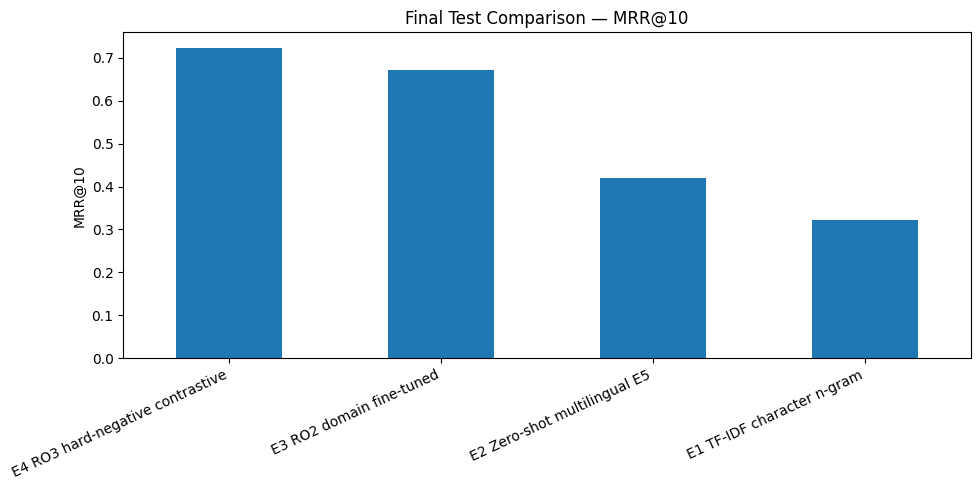

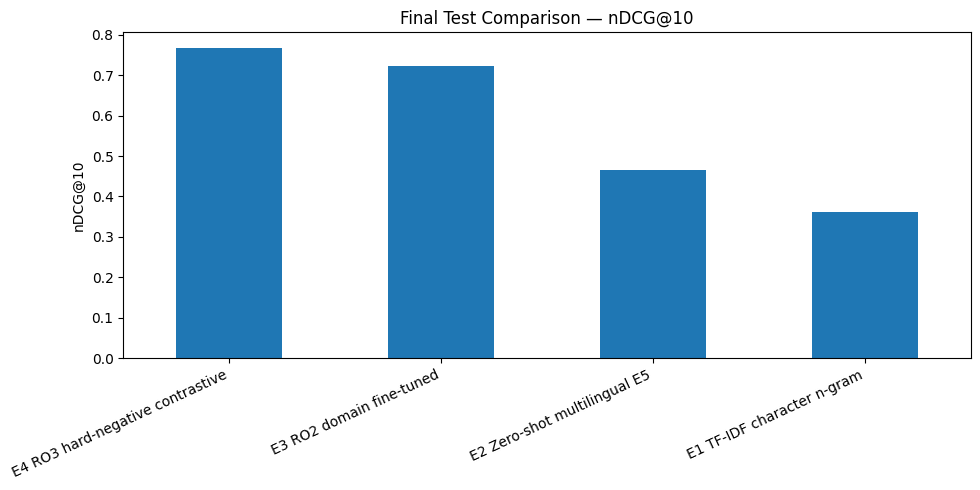

In [ ]:

plot_df = test_comparison.set_index(
    "Experiment"
)

for metric in [
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "MRR@10",
    "nDCG@10",
]:
    plt.figure(figsize=(10, 5))
    plot_df[metric].plot(kind="bar")
    plt.title(
        f"Final Test Comparison — {metric}"
    )
    plt.ylabel(metric)
    plt.xlabel("")
    plt.xticks(
        rotation=25,
        ha="right",
    )
    plt.tight_layout()
    plt.savefig(
        RESULT_DIR
        / f"final_comparison_{metric.replace('@', '_at_')}.png",
        dpi=200,
    )
    plt.show()



# Improvement and Ablation Analysis


In [ ]:

def percentage_improvement(
    new_value,
    old_value,
):
    if old_value == 0:
        return np.nan
    return (
        (new_value - old_value)
        / old_value
        * 100
    )

ablation_rows = []

for metric in [
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "MRR@10",
    "nDCG@10",
]:
    ablation_rows.append(
        {
            "Metric": metric,
            "RO2_vs_ZeroShot_%": (
                percentage_improvement(
                    ro2_test_metrics[metric],
                    zero_test_metrics[metric],
                )
            ),
            "RO3_vs_RO2_%": (
                percentage_improvement(
                    ro3_test_metrics[metric],
                    ro2_test_metrics[metric],
                )
            ),
            "RO3_vs_TFIDF_%": (
                percentage_improvement(
                    ro3_test_metrics[metric],
                    tfidf_row[metric],
                )
            ),
        }
    )

ablation_df = pd.DataFrame(
    ablation_rows
)

ablation_df.to_csv(
    RESULT_DIR / "ablation_improvements.csv",
    index=False,
)

display(ablation_df.round(2))


,Metric,RO2_vs_ZeroShot_%,RO3_vs_RO2_%,RO3_vs_TFIDF_%
0,Recall@1,70.60,10.00,149.15
1,Recall@5,51.84,5.10,104.22
2,Recall@10,43.59,3.47,85.35
3,MRR@10,60.53,7.55,124.07
4,nDCG@10,55.36,6.37,111.90



# Inspect Retrieval Errors


In [ ]:

failed_examples = selected_results[
    selected_results["rank_at_10"].isna()
].copy()

rank1_examples = selected_results[
    selected_results["rank_at_10"] == 1
].copy()

failed_examples.to_csv(
    RESULT_DIR / "best_model_top10_failures.csv",
    index=False,
)

rank1_examples.to_csv(
    RESULT_DIR / "best_model_rank1_successes.csv",
    index=False,
)

print(
    "Rank-1 successes:",
    len(rank1_examples),
)
print(
    "Outside Top-10:",
    len(failed_examples),
)

display(
    failed_examples[
        [
            "wanted_ad",
            "category_1",
            "category_2",
            "wanted_script_group",
            "top1_score",
        ]
    ].head(10)
)


Rank-1 successes: 5125
Outside Top-10: 774


,wanted_ad,category_1,category_2,wanted_script_group,top1_score
9,"Interested in buying an apartment in Malabe, i...",Property,apartment,latin_only,0.612173
44,"Looking for a land near Piliyandala town, arou...",Property,land,latin_only,0.791547
46,"Looking to buy an apartment in Wellawatta, pre...",Property,apartment,latin_only,0.664609
50,"Need a building around Colombo 3, between Gall...",Property,commercial property,latin_only,0.642428
63,Looking for a house in the Battaramulla/Pelawa...,Property,house,latin_only,0.626355
74,Interested in renting a fully furnished apartm...,Property,apartment,latin_only,0.819969
109,Looking to buy a residential plot around Piliy...,Property,land,latin_only,0.691724
110,Looking for a house to rent in Pelawatta with ...,Property,house,latin_only,0.556751
151,Interested in buying a beachfront apartment in...,Property,apartment,latin_only,0.706928
169,Looking for a land close to Hokandara or Malab...,Property,land,latin_only,0.715826



# Save a Day 2 Summary


In [ ]:

summary = {
    "selected_finetuned_model": selected_name,
    "selected_model_path": str(
        selected_model_path
    ),
    "validation_best_experiment": str(
        best_experiment
    ),
    "train_unique_pairs": int(
        len(train_unique)
    ),
    "hard_negative_triplets": int(
        len(hard_negative_df)
    ),
    "tfidf_test_metrics": {
        key: float(value)
        for key, value in tfidf_row.items()
        if key != "Top10_Failures"
    },
    "zero_shot_test_metrics": {
        key: float(value)
        for key, value
        in zero_test_metrics.items()
    },
    "ro2_test_metrics": {
        key: float(value)
        for key, value
        in ro2_test_metrics.items()
    },
    "ro3_test_metrics": {
        key: float(value)
        for key, value
        in ro3_test_metrics.items()
    },
}

with open(
    RESULT_DIR / "day2_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False,
    )
)


{
  "selected_finetuned_model": "E4 RO3 hard-negative contrastive",
  "selected_model_path": "/content/drive/MyDrive/ad_matching_research/models/ro3_hard_negative_e5",
  "validation_best_experiment": "E4 RO3 hard-negative contrastive",
  "train_unique_pairs": 27313,
  "hard_negative_triplets": 27313,
  "tfidf_test_metrics": {
    "Recall@1": 0.2524236102589274,
    "Recall@5": 0.4160019634310958,
    "Recall@10": 0.4882807706467051,
    "MRR@10": 0.3229312390068311,
    "nDCG@10": 0.3622836340097827,
    "Precision@1": 0.2524236102589274,
    "Precision@5": 0.08320039268621916,
    "Precision@10": 0.04882807706467051
  },
  "zero_shot_test_metrics": {
    "Recall@1": 0.33513314517118664,
    "Precision@1": 0.33513314517118664,
    "Recall@5": 0.5323352558596147,
    "Precision@5": 0.10646705117192294,
    "Recall@10": 0.6091544974843539,
    "Precision@10": 0.060915449748435394,
    "MRR@10": 0.41913098695525985,
    "nDCG@10": 0.464521462074716,
    "Top10_Failures": 3185.0
  },
  "ro


# Download Day 2 Results

The trained model remains safely stored in Google Drive.

Upload the downloaded `Day2_results.zip` to ChatGPT for the RO4 notebook.


In [ ]:

zip_path = shutil.make_archive(
    "/content/Day2_results",
    "zip",
    RESULT_DIR,
)

print("Created:", zip_path)

from google.colab import files
files.download(zip_path)


Created: /content/Day2_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Thesis-Ready Methodology Statement

> A multilingual dense-retrieval bi-encoder was initialized using the multilingual E5-small checkpoint. Wanted advertisements were encoded as queries and offering advertisements as passages using the task-specific prefixes required by the model. The maximum sequence length was set to 256 tokens due to the available Colab GPU resources. First, the pretrained model was evaluated without domain adaptation. For RO2, the encoder was fine-tuned on unique wanted–offering positive pairs using Multiple Negatives Ranking Loss, where other documents within each batch served as negative examples. A no-duplicates batch sampler was used to reduce false-negative collisions. For RO3, hard negatives were mined from the RO2 embedding space. Candidate negatives were preferentially selected from the same subcategory while maintaining a similarity margin below the labelled positive; same-category and non-target candidates were used as fallbacks. The RO2 model was then further fine-tuned with anchor–positive–negative triplets. Models were selected using validation MRR@10 and evaluated on the held-out test set using Recall@1, Recall@5, Recall@10, Precision@K, MRR@10, and nDCG@10. Performance was additionally analysed by marketplace category, subcategory, and query script group.
